In [12]:
# Get columns with string (or object) data types
df=pd.read_csv("processed/linux_kernel_logs.csv")
string_columns = df.select_dtypes(include=['object']).columns
print(string_columns)


Index(['timestamp', 'hostname', 'service', 'message', 'matched_patterns',
       'fault_type'],
      dtype='object')


In [15]:
from sklearn.preprocessing import LabelEncoder

# Apply label encoding to categorical string columns
encoder = LabelEncoder()

for col in ['hostname', 'service', 'fault_type']:  # Adjust column names accordingly
    df[col] = encoder.fit_transform(df[col])

df = df.drop(columns=['timestamp','message','matched_patterns'])
string_columns = df.select_dtypes(include=['object']).columns
print(string_columns)


Index([], dtype='object')


In [16]:
df.head()


,hostname,service,is_kernel_related,is_failure,severity,message_length,word_count,fault_type,has_hex_address,has_memory_value,has_process_id
0,0,8,True,False,0,45,7,4,False,False,False
1,0,8,True,False,0,143,19,4,False,False,False
2,0,8,True,False,0,31,4,4,False,False,False
3,0,8,True,False,0,55,5,4,False,False,False
4,0,8,True,False,0,57,5,4,False,False,False


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00      2314
        True       1.00      1.00      1.00      3153

    accuracy                           1.00      5467
   macro avg       1.00      1.00      1.00      5467
weighted avg       1.00      1.00      1.00      5467



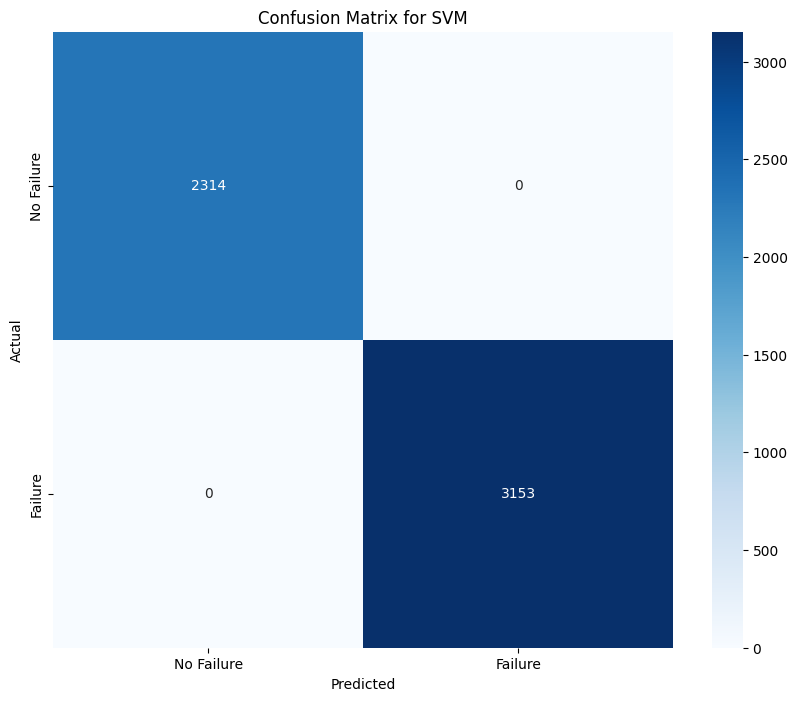

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd




# Data Preparation (assuming you have a DataFrame `df` and target column `is_failure`)
X = df.drop('is_failure', axis=1)  # Drop the target column
y = df['is_failure']

# Train-test split (adjust for your needs)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train SVM
svm = SVC(kernel='rbf', random_state=42)  # You can try 'linear' or other kernels
svm.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = svm.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



if X.shape[1] == 2:  # Only if the dataset has two features, otherwise skip this step
    plt.figure(figsize=(8, 6))
    h = .02  # Step size in the mesh
    x_min, x_max = X['message_length'].min() - 1, X['message_length'].max() + 1
    y_min, y_max = X['word_count'].min() - 1, X['word_count'].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.75, cmap='coolwarm')
    plt.scatter(X['message_length'], X['word_count'], c=y, edgecolors='k', marker='o', cmap='coolwarm')
    plt.title('SVM Decision Boundary')
    plt.xlabel('message_length')
    plt.ylabel('word_count')
    plt.show()



In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your features are in 'X' and target is 'y'
X = df.drop(columns=['is_failure'])  # Features
y = df['is_failure']  # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


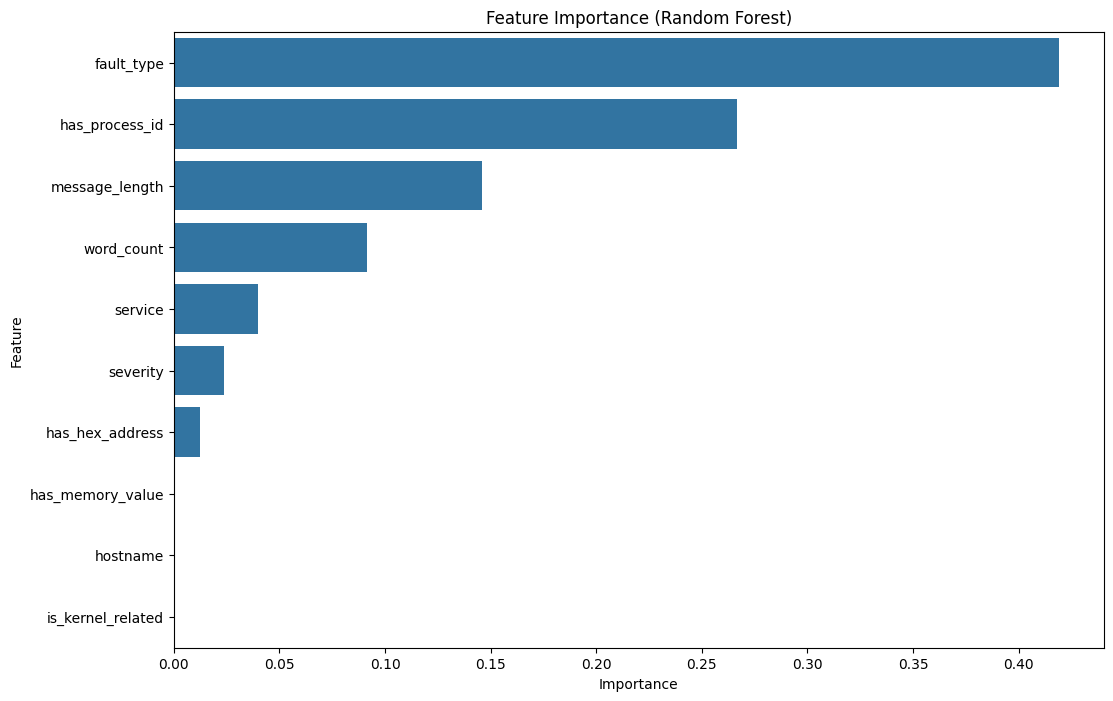

In [19]:
# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame to show feature importances with corresponding feature names
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the importance values in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance (Random Forest)')
plt.show()


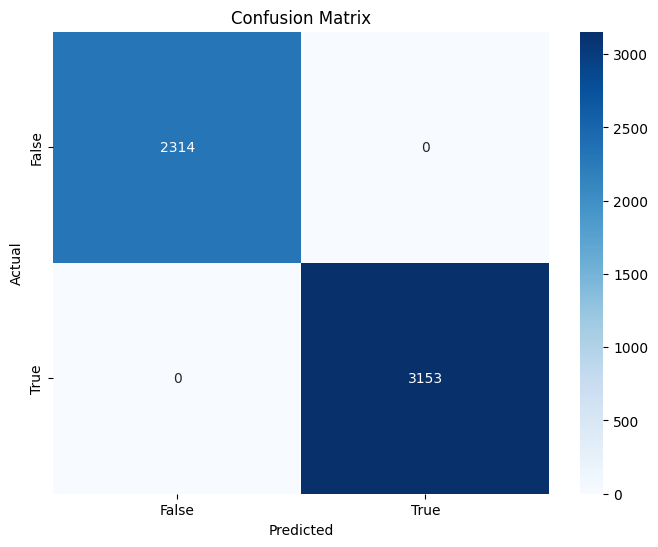

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


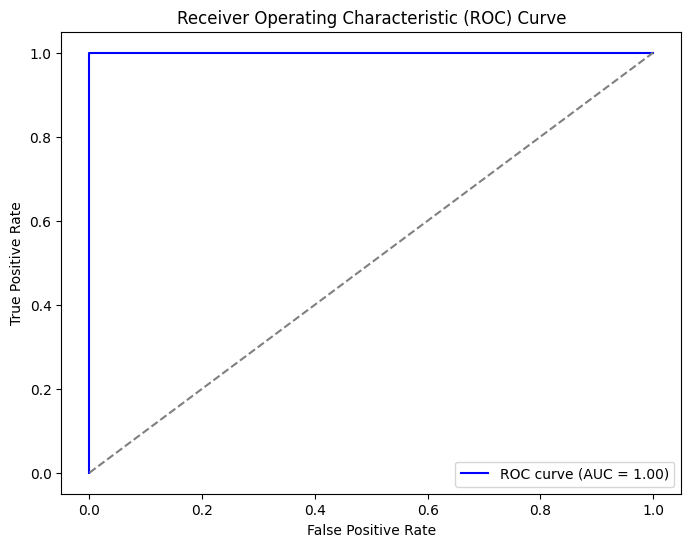

In [21]:
# Compute ROC curve and AUC for each class
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1], pos_label=model.classes_[1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


In [22]:
# Classification Report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       1.00      1.00      1.00      2314
        True       1.00      1.00      1.00      3153

    accuracy                           1.00      5467
   macro avg       1.00      1.00      1.00      5467
weighted avg       1.00      1.00      1.00      5467

